# 04 - Real-Time Feedback with tProc v2

**Objective:** Learn how to read measurement results directly on the tProc and make real-time decisions (conditional pulses, active reset, adaptive measurements).

## 1. Setup

In [1]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging

from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Connect to the board (adjust the path to your firmware)
BITSTREAM_PATH = 'qick_216.bit'#'/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

## 2. Understanding tProc Feedback

The tProc can read accumulated IQ values from the readout module and use them to make decisions in real-time. This enables:
- Conditional pulse sequences (e.g., play a second pulse only if a measurement exceeds a threshold)
- Active reset (play a pulse conditioned on measurement outcome)
- Adaptive measurements (change experiment parameters based on results)

**Key commands:**
- `read_input(ro_ch)` - Reads the accumulated IQ value from a readout channel into registers `s_port_l` (I) and `s_port_h` (Q)
- `cond_jump(label, condition)` - Conditional jump based on register values
- `read_and_jump()` - Convenience method that combines both

**Important:** After triggering a readout, you must wait for it to complete before reading the value. This requires tuning the `read_wait` parameter.

## 3. Measuring Readout Latency

Before using feedback, you need to determine the correct `read_wait` time. This is the delay between triggering a readout and when the accumulated value is available to the tProc.

In [2]:
class LatencyMeasurementProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define a constant test pulse
        self.add_pulse(ch=gen_ch, name="test_pulse", 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'])

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch, 
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        # Play pulse
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        
        # Trigger readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        
        # Wait for readout to complete
        self.wait_auto(cfg['read_wait'])
        
        # Read the accumulated I/Q value into tProc registers
        self.read_input(ro_ch=cfg['ro_ch'])
        
        # Store the values to data memory for reading back from Python
        self.write_dmem(addr=0, src='s_port_l')  # I value (lower 32 bits)
        self.write_dmem(addr=1, src='s_port_h')  # Q value (upper 32 bits)

# Configuration
config_latency = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'pulse_len': 0.025,
    'pulse_phase': 0,
    'ro_phase': 0,
    'gain': 1.0,
    'trig_time': 0.25,
    'ro_len': 0.1,
    'read_wait': 0.1  # This needs to be tuned
}

# Run the measurement
prog = LatencyMeasurementProgram(soccfg, reps=100, final_delay=0.5, cfg=config_latency)

# Acquire data - this also gives us the buffered readout values
iq_data = prog.acquire(soc, rounds=1, progress=False)

# Get the feedback readout values from data memory
# read_mem returns a numpy array of int32 values
I_feedback = soc.read_mem(length=1, mem_sel='dmem', addr=0)[0]
Q_feedback = soc.read_mem(length=1, mem_sel='dmem', addr=1)[0]

# Get the buffered readout values (from acquire())
# Shape is (1, 2) → (rounds, IQ)
I_buffered = iq_data[0][0, 0] * prog.cfg['ro_len']  # round 0, I
Q_buffered = iq_data[0][0, 1] * prog.cfg['ro_len']  # round 0, Q

print(f"Buffered I/Q: ({I_buffered:.0f}, {Q_buffered:.0f})")
print(f"Feedback I/Q: ({I_feedback}, {Q_feedback})")

if I_feedback == I_buffered and Q_feedback == Q_buffered:
    print("\n✓ Feedback and buffered readouts match! Latency is correct.")
else:
    print("\n✗ Feedback and buffered readouts do NOT match! Increase 'read_wait'.")

Buffered I/Q: (-0, 0)
Feedback I/Q: (12, 5)

✗ Feedback and buffered readouts do NOT match! Increase 'read_wait'.


**Explanation:**
- The buffered readout (from `acquire()`) is reliable and length-normalized
- The feedback readout (via `read_input()`) gives raw accumulated values
- If they don't match, increase `read_wait` until they do
- Once tuned, this `read_wait` value can be used for all feedback experiments

## 4. Conditional Pulse: If-Then-Else on the tProc

Now let's use feedback to conditionally play a second pulse based on the measurement result.

  0%|          | 0/10 [00:00<?, ?it/s]

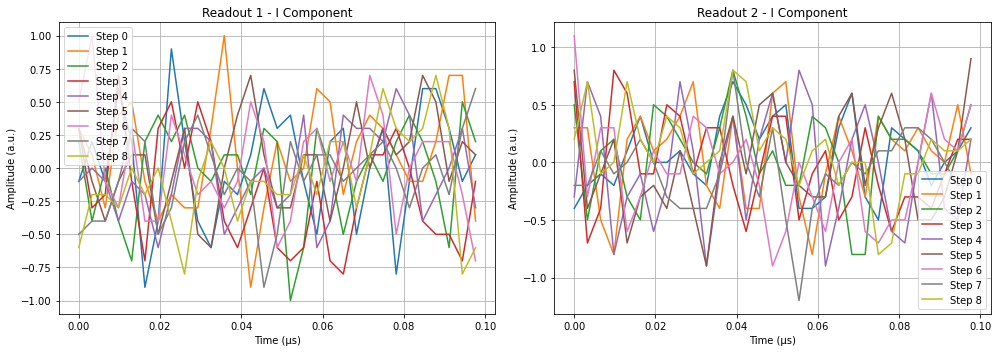

In [3]:
class ConditionalPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("feedback_sweep", self.cfg["steps"])

        # Define pulses
        self.add_pulse(ch=gen_ch, name="cond_pulse", 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'])

        # Configure readout with phase rotation for optimal sensitivity
        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch, 
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        # First pulse and readout (the measurement)
        self.pulse(ch=cfg['gen_ch'], name="cond_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # Wait for readout to complete (tuned latency)
        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        # Second readout (for feedback decision)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # If I >= threshold, jump to 'SKIP_PULSE'
        self.read_and_jump(ro_ch=cfg['ro_ch'], 
                          component='I', 
                          threshold=cfg['threshold'], 
                          test='>=', 
                          label='SKIP_PULSE')
        
        # --- This code is skipped if condition is true ---
        # Second pulse (only played if I < threshold)
        self.pulse(ch=cfg['gen_ch'], name="cond_pulse", t=0, tag='conditional_pulse')
        
        # Label for conditional jump
        self.label("SKIP_PULSE")

# Configuration
config_conditional = {
    'steps': 9,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'read_wait': 0.1,      # Tuned from latency measurement
    'extra_delay': 0.2,    # Extra safety margin
    'threshold': 0,        # Threshold on I component
    'ro_len': 0.1,
    'pulse_len': 0.025,
    'pulse_phase': 0,
    'ro_phase': 0,         # Optimize via rotation
    'gain': QickSweep1D("feedback_sweep", -1.0, 1.0)
}

# Run the experiment
prog = ConditionalPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config_conditional)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Plot results for each sweep step
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i_read in range(2):
    ax = axes[i_read]
    for i_step, iq_point in enumerate(iq_data[0]):
        ax.plot(time_axis, iq_point[i_read, :, 0], label=f"Step {i_step}")
    ax.set_title(f"Readout {i_read+1} - I Component")
    ax.set_xlabel("Time (µs)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Explanation:**
- The first readout measures the result
- If `I >= threshold`, the tProc jumps to `SKIP_PULSE`, skipping the second pulse
- If `I < threshold`, the second pulse is played
- This runs entirely on the tProc with no Python involvement

**Note:** The threshold comparison uses raw (non-normalized) accumulated values. The same `read_wait` tuned from the latency measurement is critical here.

## 5. Active Reset

A common feedback application is active reset: play a reset pulse conditioned on the qubit state.

In [4]:
class ActiveResetProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Measurement pulse
        self.add_pulse(ch=gen_ch, name="measure_pulse", 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=0, gain=1.0)
        
        # Reset pulse (π pulse to bring qubit to ground)
        self.add_pulse(ch=gen_ch, name="reset_pulse", 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['reset_len'],
                       phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch, 
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        # Measurement
        self.pulse(ch=cfg['gen_ch'], name="measure_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        # If I >= threshold (qubit in excited state), play reset pulse
        self.read_and_jump(ro_ch=cfg['ro_ch'], 
                          component='I', 
                          threshold=cfg['threshold'], 
                          test='>=', 
                          label='NO_RESET')
        
        self.pulse(ch=cfg['gen_ch'], name="reset_pulse", t=0, tag='reset_pulse')
        self.label("NO_RESET")

config_reset = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'read_wait': 0.1,
    'extra_delay': 0.2,
    'threshold': 0,
    'ro_len': 0.1,
    'pulse_len': 0.025,
    'reset_len': 0.05,
    'ro_phase': 0
}

prog = ActiveResetProgram(soccfg, reps=100, final_delay=0.5, cfg=config_reset)

# In a real experiment, you would verify that the reset works by
# measuring the state after reset. This would require a second readout.
print("Active reset program created successfully.")
print("In practice, you would add a verification readout after the reset pulse.")

Active reset program created successfully.
In practice, you would add a verification readout after the reset pulse.


## 6. Visualizing the Feedback Decision

Let's examine how the threshold affects the conditional pulse decision.

  0%|          | 0/2000 [00:00<?, ?it/s]

iq_data length: 1
iq_data[0] shape: (2, 2000, 2)


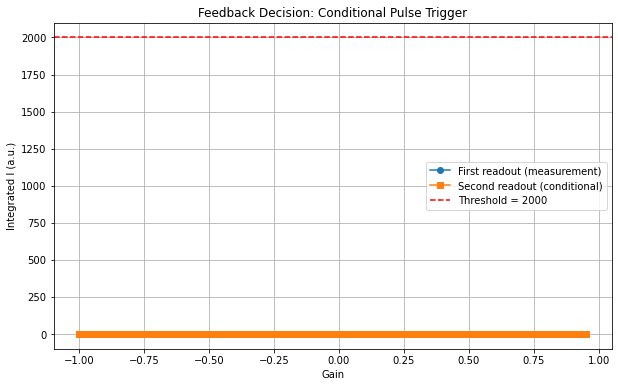

Conditional pulse played for 1003 out of 2000 steps
Trigger threshold crossed when I_first >= 2000


In [6]:
# Run a sweep with varying gain and observe when the conditional pulse triggers
config_conditional['steps'] = 2000
config_conditional['threshold'] = 2000  # Set a fixed threshold

prog = ConditionalPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config_conditional)

# Acquire data without decimation to get single-shot values
iq_data = prog.acquire(soc, rounds=1)
gains = prog.get_pulse_param('cond_pulse', 'gain', as_array=True)

print("iq_data length:", len(iq_data))
for i, d in enumerate(iq_data):
    print(f"iq_data[{i}] shape:", d.shape)
# The shape: (reps, steps, readout_length, I/Q)
# For feedback, we care about the integrated value (sum over readout window)
# Shape: (readouts, steps, IQ)
# iq_data[0][readout, step, I/Q]

I_first  = iq_data[0][0, :, 0] * prog.cfg['ro_len']  # primer readout, I, todos los steps
I_second = iq_data[0][1, :, 0] * prog.cfg['ro_len']  # segundo readout, I, todos los steps

plt.figure(figsize=(10, 6))
plt.plot(gains, I_first,  'o-', label='First readout (measurement)')
plt.plot(gains, I_second, 's-', label='Second readout (conditional)')
plt.axhline(y=config_conditional['threshold'], color='r', linestyle='--', 
            label=f'Threshold = {config_conditional["threshold"]}')
plt.xlabel('Gain')
plt.ylabel('Integrated I (a.u.)')
plt.title('Feedback Decision: Conditional Pulse Trigger')
plt.legend()
plt.grid(True)
plt.show()

triggered = I_second > 0
print(f"Conditional pulse played for {np.sum(triggered)} out of {len(gains)} steps")
print(f"Trigger threshold crossed when I_first >= {config_conditional['threshold']}")

**Observations:**
- The first readout (measurement) varies with gain as expected
- The second readout (conditional) is zero when the condition fails (pulse not played)
- The second readout has a signal only when the conditional pulse was actually played
- The threshold determines the decision boundary

## 7. Summary

You have learned:
- How to measure and tune readout latency for reliable feedback
- How to read accumulated IQ values directly on the tProc using `read_input()`
- How to implement conditional pulses using `read_and_jump()`
- How to implement active reset for qubit state initialization
- How to verify that your feedback logic is working correctly

**Key concepts:**
- `read_wait` must be tuned to match your hardware latency
- Feedback uses raw (non-normalized) accumulated values
- The tProc can make decisions in microseconds, enabling active reset and adaptive protocols
- Always verify feedback behavior with benchmark measurements
- Use `read_mem()` to retrieve values written to data memory

**Next steps:** Proceed to [`05_Dynamic_Parameters_Subroutines.ipynb`](./05_Dynamic_Parameters_Subroutines.ipynb) to learn how to modify pulse parameters dynamically and use subroutines for code reuse.